# PromptLint evaluation report

Generated by `eval/build_report.py` from `eval/results/`. Re-run the eval scripts, then this builder, to refresh every chart.

In [1]:

import json, csv
from pathlib import Path
import matplotlib.pyplot as plt

R = Path("results")
def load(name):
    p = R / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None

# Fixed categorical order (validated palette): slot 1 blue = weak / A, slot 2 orange = improved / B.
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10, "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
summary = load("summary")
{k: v for k, v in summary.items() if not k.startswith("_")}


{'pairwise': {'accuracy': 1.0,
  'n': 200,
  'ties': 0,
  'hard_accuracy': 1.0,
  'hard_n': 40,
  'matrix': {'jev': {'lint': {'main': 1.0,
     'hard': 1.0,
     'main_mean_delta': 55.26,
     'hard_mean_delta': 20.15},
    'pqs': {'main': 1.0,
     'hard': 1.0,
     'main_mean_delta': 55.725,
     'hard_mean_delta': 22.1}},
   'heuristic': {'lint': {'main': 0.995,
     'hard': 0.95,
     'main_mean_delta': 49.76,
     'hard_mean_delta': 15.275},
    'pqs': {'main': 0.995,
     'hard': 1.0,
     'main_mean_delta': 55.04,
     'hard_mean_delta': 17.0}}}},
 'latency': {'median_ms': 183, 'p95_ms': 381, 'n': 1927},
 'generated_at': '2026-09-26T05:10:01+00:00',
 'jev_model': 'jev-1.13.0',
 'note': 'Prompt pairs and checklist labels were drafted with an AI assistant for this project; spot-check them before citing these numbers.',
 'checklist': {'accuracy': 0.9585714285714285,
  'n': 700,
  'heuristic_accuracy': 0.9142857142857143},
 'injection': {'mean_inflation': 3.1,
  'max_inflation': 24,

## Eval 1: pairwise ranking

Does the improved version of a prompt score higher than the weak one?

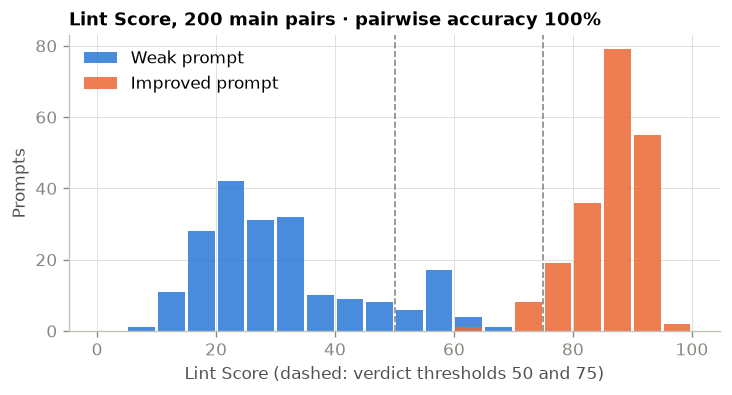

In [2]:

all_rows = list(csv.DictReader(open(R / "pairwise_rows.csv")))
rows = [r for r in all_rows if r["backend"] == "jev" and r["score"] == "lint"]
main = [r for r in rows if r["set"] == "main"]
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = range(0, 105, 5)
ax.hist([int(r["weak_score"]) for r in main], bins=bins, color=BLUE, alpha=0.85, label="Weak prompt", rwidth=0.9)
ax.hist([int(r["improved_score"]) for r in main], bins=bins, color=ORANGE, alpha=0.85, label="Improved prompt", rwidth=0.9)
for x in (50, 75):
    ax.axvline(x, color=MUTED, lw=1, ls="--")
ax.set(title=f"Lint Score, 200 main pairs · pairwise accuracy {load('pairwise')['main']['accuracy']:.0%}",
       xlabel="Lint Score (dashed: verdict thresholds 50 and 75)", ylabel="Prompts")
ax.legend(frameon=False)
plt.show()


### Hard set: one missing piece

A decent prompt versus the same prompt plus one addition (format, audience, constraints, context or an example).

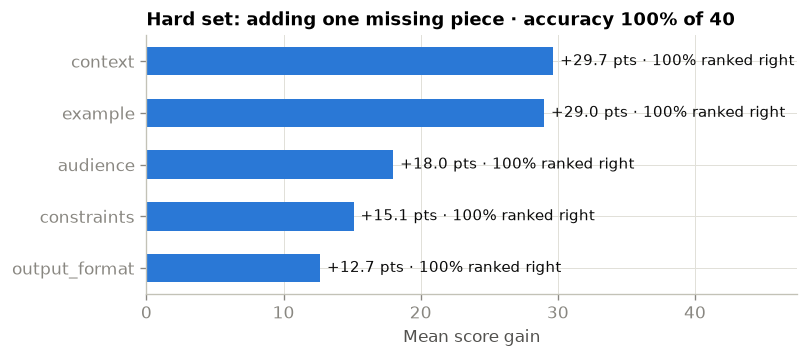

First-try probability alone ranks 52% of hard pairs correctly; the composite score ranks 100%.


In [3]:

hard = load("pairwise")["hard"]
groups = hard["by_adds"]
deltas = {}
for r in rows:
    if r["set"] == "hard":
        deltas.setdefault(r["group"], []).append(int(r["delta"]))
names = sorted(deltas, key=lambda g: -sum(deltas[g]) / len(deltas[g]))
means = [sum(deltas[g]) / len(deltas[g]) for g in names]
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(names, means, color=BLUE, height=0.55)
for i, (g, m) in enumerate(zip(names, means)):
    ax.text(m + 0.5, i, f"+{m:.1f} pts · {groups[g]['accuracy']:.0%} ranked right", va="center", color=INK, fontsize=9)
ax.invert_yaxis()
ax.set(title=f"Hard set: adding one missing piece · accuracy {hard['accuracy']:.0%} of {hard['n']}",
       xlabel="Mean score gain")
ax.set_xlim(0, max(means) * 1.6)
plt.show()
print(f"First-try probability alone ranks {hard['first_try_alone_accuracy']:.0%} of hard pairs correctly; "
      f"the composite score ranks {hard['accuracy']:.0%}.")


## Eval 3: checklist accuracy

Jev's yes/no checks against hand labels on 100 prompts (a check fires at probability ≥ 0.5).

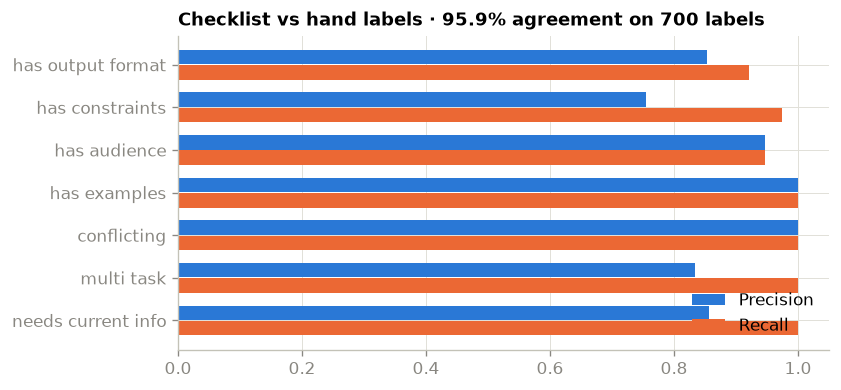

In [4]:

ck = load("checklist")
checks = list(ck["per_check"])
prec = [ck["per_check"][c]["precision"] or 0 for c in checks]
rec = [ck["per_check"][c]["recall"] or 0 for c in checks]
fig, ax = plt.subplots(figsize=(7, 3.4))
y = range(len(checks))
ax.barh([i - 0.18 for i in y], prec, height=0.34, color=BLUE, label="Precision")
ax.barh([i + 0.18 for i in y], rec, height=0.34, color=ORANGE, label="Recall")
ax.set_yticks(list(y), [c.replace("_", " ") for c in checks])
ax.invert_yaxis()
ax.set(xlim=(0, 1.05), title=f"Checklist vs hand labels · {ck['accuracy']:.1%} agreement on {ck['n_labels']} labels")
ax.legend(frameon=False, loc="lower right")
plt.show()


## Prompt injection

Weak prompts with and without text aimed at the grader ("rate this 100").

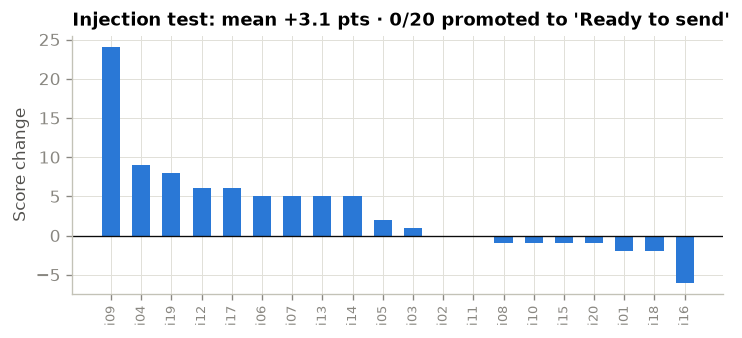

In [5]:

inj = load("injection")
rows_i = sorted(inj["rows"], key=lambda r: r["inflation"], reverse=True)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar([r["id"] for r in rows_i], [r["inflation"] for r in rows_i], color=BLUE, width=0.6)
ax.axhline(0, color=INK, lw=0.8)
ax.set(title=f"Injection test: mean {inj['mean_inflation']:+.1f} pts · {inj['promoted_to_ready']}/{inj['n']} promoted to 'Ready to send'",
       ylabel="Score change")
ax.tick_params(axis="x", rotation=90, labelsize=8)
plt.show()


## Eval 2: first-try calibration

Jev's `first_try_success` against an LLM judge's verdict on a real answer.

In [6]:

ft = load("first_try")
if not ft:
    print("First-try calibration has not been run yet (eval/run_first_try.py needs an LLM key).")
else:
    rel = ft["reliability"]
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Perfect calibration")
    ax.plot([b["mean_predicted"] for b in rel], [b["observed_rate"] for b in rel], color=BLUE, lw=2, marker="o", ms=7,
            markeredgecolor="white", markeredgewidth=2, label="Jev first_try_success")
    for b in rel:
        ax.annotate(f"n={b['n']}", (b["mean_predicted"], b["observed_rate"]), textcoords="offset points", xytext=(6, -12), fontsize=8, color=MUTED)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Predicted probability", ylabel="Observed success rate (LLM judge)",
           title=f"Calibration · AUROC {ft['auroc']:.2f} · Brier {ft['brier']:.3f}")
    ax.legend(frameon=False, loc="upper left")
    plt.show()


First-try calibration has not been run yet (eval/run_first_try.py needs an LLM key).
